# Day 17 — Customer Segmentation (RFM)

## Objective

Segment customers using Recency, Frequency, and Monetary (RFM) analysis to
identify customer groups with different levels of value and engagement, then
recommend an appropriate action for each segment.

## Dataset Selection

The project's primary Titanic dataset cannot support genuine RFM analysis because
it contains passenger-level observations but no customer transaction history,
purchase dates, transaction identifiers, or monetary purchase values.

Therefore, this task uses the real **UCI Online Retail dataset** as an explicit
dataset substitution. The UCI dataset contains transaction-level fields including
`InvoiceNo`, `InvoiceDate`, `Quantity`, `UnitPrice`, and `CustomerID`, which allow
Recency, Frequency, and Monetary values to be calculated.

**Source:** UCI Machine Learning Repository — Online Retail Dataset

## RFM Definitions

- **Recency:** Number of days since a customer's most recent purchase.
- **Frequency:** Number of distinct purchase transactions made by the customer.
- **Monetary:** Total customer spend across valid transactions.

## Planned Method

1. Validate and clean the transaction data.
2. Calculate RFM values at customer level.
3. Score Recency, Frequency, and Monetary dimensions into quintiles.
4. Combine RFM scores into named customer segments.
5. Profile segment size and value.
6. Assign a recommended action to every segment.
7. Validate that segments are distinct and stable.

## Important Note

This is a customer segmentation exercise, not a causal experiment. Segment labels
and recommended actions are analytical interpretations based on observed
transaction behavior.

In [1]:
from pathlib import Path

# List all CSV files available in the project
data_dir = Path("data")

csv_files = sorted(data_dir.glob("*.csv"))

print("CSV files found:")
for file in csv_files:
    print("-", file)

print("\nNumber of CSV files:", len(csv_files))

CSV files found:
- data/titanic.csv
- data/titanic_cleaned.csv

Number of CSV files: 2


In [3]:
import pandas as pd

# Load the UCI Online Retail dataset
retail_df = pd.read_excel("data/online_retail/Online Retail.xlsx")

print("Dataset shape:", retail_df.shape)

print("\nColumns:")
print(retail_df.columns.tolist())

print("\nFirst 5 rows:")
display(retail_df.head())

print("\nData types:")
print(retail_df.dtypes)

print("\nMissing values:")
print(retail_df.isna().sum())

Dataset shape: (541909, 8)

Columns:
['InvoiceNo', 'StockCode', 'Description', 'Quantity', 'InvoiceDate', 'UnitPrice', 'CustomerID', 'Country']

First 5 rows:


,InvoiceNo,StockCode,Description,Quantity,InvoiceDate,UnitPrice,CustomerID,Country
0,536365,85123A,WHITE HANGING HEART T-LIGHT HOLDER,6,2010-12-01 08:26:00,2.55,17850.0,United Kingdom
1,536365,71053,WHITE METAL LANTERN,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
2,536365,84406B,CREAM CUPID HEARTS COAT HANGER,8,2010-12-01 08:26:00,2.75,17850.0,United Kingdom
3,536365,84029G,KNITTED UNION FLAG HOT WATER BOTTLE,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom
4,536365,84029E,RED WOOLLY HOTTIE WHITE HEART.,6,2010-12-01 08:26:00,3.39,17850.0,United Kingdom



Data types:
InvoiceNo              object
StockCode              object
Description            object
Quantity                int64
InvoiceDate    datetime64[us]
UnitPrice             float64
CustomerID            float64
Country                   str
dtype: object

Missing values:
InvoiceNo           0
StockCode           0
Description      1454
Quantity            0
InvoiceDate         0
UnitPrice           0
CustomerID     135080
Country             0
dtype: int64


In [4]:
# Audit fields that affect RFM validity

print("Missing CustomerID:", retail_df["CustomerID"].isna().sum())

print("\nInvoice number prefixes:")
print(
    retail_df["InvoiceNo"]
    .astype(str)
    .str[0]
    .value_counts()
    .head(10)
)

print("\nTransactions with negative Quantity:")
print((retail_df["Quantity"] < 0).sum())

print("\nTransactions with zero Quantity:")
print((retail_df["Quantity"] == 0).sum())

print("\nTransactions with non-positive UnitPrice:")
print((retail_df["UnitPrice"] <= 0).sum())

print("\nDate range:")
print("Earliest:", retail_df["InvoiceDate"].min())
print("Latest:", retail_df["InvoiceDate"].max())

print("\nUnique customers with CustomerID:")
print(retail_df["CustomerID"].nunique())

Missing CustomerID: 135080

Invoice number prefixes:
InvoiceNo
5    532618
C      9288
A         3
Name: count, dtype: int64

Transactions with negative Quantity:
10624

Transactions with zero Quantity:
0

Transactions with non-positive UnitPrice:
2517

Date range:
Earliest: 2010-12-01 08:26:00
Latest: 2011-12-09 12:50:00

Unique customers with CustomerID:
4372


In [5]:
# Investigate cancellations and non-positive transaction values

invoice_str = retail_df["InvoiceNo"].astype(str)
is_cancel = invoice_str.str.startswith("C")

print("Cancellation rows:", is_cancel.sum())
print("Cancellation rows with negative Quantity:",
      ((is_cancel) & (retail_df["Quantity"] < 0)).sum())

print("Negative-quantity rows on non-cancellation invoices:",
      ((~is_cancel) & (retail_df["Quantity"] < 0)).sum())

print("\nCancellation rows with missing CustomerID:",
      ((is_cancel) & (retail_df["CustomerID"].isna())).sum())

print("\nNon-positive UnitPrice rows with valid CustomerID:",
      ((retail_df["UnitPrice"] <= 0) & (retail_df["CustomerID"].notna())).sum())

print("Non-positive UnitPrice rows with missing CustomerID:",
      ((retail_df["UnitPrice"] <= 0) & (retail_df["CustomerID"].isna())).sum())

print("\nSample cancellation records:")
display(
    retail_df.loc[is_cancel,
                  ["InvoiceNo", "Quantity", "InvoiceDate",
                   "UnitPrice", "CustomerID"]].head(10)
)

Cancellation rows: 9288
Cancellation rows with negative Quantity: 9288
Negative-quantity rows on non-cancellation invoices: 1336

Cancellation rows with missing CustomerID: 383

Non-positive UnitPrice rows with valid CustomerID: 40
Non-positive UnitPrice rows with missing CustomerID: 2477

Sample cancellation records:


,InvoiceNo,Quantity,InvoiceDate,UnitPrice,CustomerID
141,C536379,-1,2010-12-01 09:41:00,27.50,14527.0
154,C536383,-1,2010-12-01 09:49:00,4.65,15311.0
235,C536391,-12,2010-12-01 10:24:00,1.65,17548.0
236,C536391,-24,2010-12-01 10:24:00,0.29,17548.0
237,C536391,-24,2010-12-01 10:24:00,0.29,17548.0
238,C536391,-24,2010-12-01 10:24:00,0.29,17548.0
239,C536391,-12,2010-12-01 10:24:00,3.45,17548.0
240,C536391,-12,2010-12-01 10:24:00,1.65,17548.0
241,C536391,-24,2010-12-01 10:24:00,1.65,17548.0
939,C536506,-6,2010-12-01 12:38:00,4.25,17897.0


In [6]:
# Create a clean transaction dataset for RFM analysis

rfm_transactions = retail_df.copy()

# Identify cancellation invoices
rfm_transactions["is_cancellation"] = (
    rfm_transactions["InvoiceNo"].astype(str).str.startswith("C")
)

# Keep only attributable, positive-value purchase transactions
rfm_transactions = rfm_transactions[
    rfm_transactions["CustomerID"].notna()
    & (~rfm_transactions["is_cancellation"])
    & (rfm_transactions["Quantity"] > 0)
    & (rfm_transactions["UnitPrice"] > 0)
].copy()

# Calculate line-level transaction value
rfm_transactions["TotalAmount"] = (
    rfm_transactions["Quantity"] * rfm_transactions["UnitPrice"]
)

print("Original rows:", len(retail_df))
print("Clean RFM transaction rows:", len(rfm_transactions))
print("Rows removed:", len(retail_df) - len(rfm_transactions))

print("\nUnique customers retained:", rfm_transactions["CustomerID"].nunique())

print("\nRemaining invalid quantities:",
      (rfm_transactions["Quantity"] <= 0).sum())

print("Remaining invalid prices:",
      (rfm_transactions["UnitPrice"] <= 0).sum())

print("Remaining missing CustomerID:",
      rfm_transactions["CustomerID"].isna().sum())

print("Remaining cancellation invoices:",
      rfm_transactions["is_cancellation"].sum())

print("\nTransaction value summary:")
print(rfm_transactions["TotalAmount"].describe().round(2))

Original rows: 541909
Clean RFM transaction rows: 397884
Rows removed: 144025

Unique customers retained: 4338

Remaining invalid quantities: 0
Remaining invalid prices: 0
Remaining missing CustomerID: 0
Remaining cancellation invoices: 0

Transaction value summary:
count    397884.00
mean         22.40
std         309.07
min           0.00
25%           4.68
50%          11.80
75%          19.80
max      168469.60
Name: TotalAmount, dtype: float64


In [7]:
# Final validation of the clean RFM transaction dataset

print("Clean transaction shape:", rfm_transactions.shape)
print("Unique customers:", rfm_transactions["CustomerID"].nunique())
print("Unique invoices:", rfm_transactions["InvoiceNo"].nunique())

print("\nValidation checks:")
print("Missing CustomerID:", rfm_transactions["CustomerID"].isna().sum())
print("Non-positive Quantity:", (rfm_transactions["Quantity"] <= 0).sum())
print("Non-positive UnitPrice:", (rfm_transactions["UnitPrice"] <= 0).sum())
print("Non-positive TotalAmount:", (rfm_transactions["TotalAmount"] <= 0).sum())
print(
    "Cancellation invoices:",
    rfm_transactions["InvoiceNo"].astype(str).str.startswith("C").sum()
)

print("\nDate range:")
print("First transaction:", rfm_transactions["InvoiceDate"].min())
print("Last transaction:", rfm_transactions["InvoiceDate"].max())

Clean transaction shape: (397884, 10)
Unique customers: 4338
Unique invoices: 18532

Validation checks:
Missing CustomerID: 0
Non-positive Quantity: 0
Non-positive UnitPrice: 0
Non-positive TotalAmount: 0
Cancellation invoices: 0

Date range:
First transaction: 2010-12-01 08:26:00
Last transaction: 2011-12-09 12:50:00


In [8]:
# Calculate Recency, Frequency, and Monetary value per customer

snapshot_date = rfm_transactions["InvoiceDate"].max() + pd.Timedelta(days=1)

rfm = (
    rfm_transactions
    .groupby("CustomerID")
    .agg(
        last_purchase_date=("InvoiceDate", "max"),
        Frequency=("InvoiceNo", "nunique"),
        Monetary=("TotalAmount", "sum")
    )
    .reset_index()
)

rfm["Recency"] = (
    snapshot_date - rfm["last_purchase_date"]
).dt.days

# Arrange columns in standard RFM order
rfm = rfm[
    ["CustomerID", "Recency", "Frequency", "Monetary", "last_purchase_date"]
]

print("RFM customer count:", len(rfm))
print("Snapshot date:", snapshot_date)

print("\nRFM sample:")
display(rfm.head())

print("\nRFM summary:")
display(
    rfm[["Recency", "Frequency", "Monetary"]]
    .describe()
    .round(2)
)

RFM customer count: 4338
Snapshot date: 2011-12-10 12:50:00

RFM sample:


,CustomerID,Recency,Frequency,Monetary,last_purchase_date
0,12346.0,326,1,77183.60,2011-01-18 10:01:00
1,12347.0,2,7,4310.00,2011-12-07 15:52:00
2,12348.0,75,4,1797.24,2011-09-25 13:13:00
3,12349.0,19,1,1757.55,2011-11-21 09:51:00
4,12350.0,310,1,334.40,2011-02-02 16:01:00



RFM summary:


,Recency,Frequency,Monetary
count,4338.00,4338.00,4338.00
mean,92.54,4.27,2054.27
std,100.01,7.70,8989.23
min,1.00,1.00,3.75
25%,18.00,1.00,307.41
50%,51.00,2.00,674.48
75%,142.00,5.00,1661.74
max,374.00,209.00,280206.02


In [9]:
# Score each RFM dimension into five quintiles
# Recency: lower is better
# Frequency and Monetary: higher is better

rfm["R_score"] = pd.qcut(
    rfm["Recency"].rank(method="first"),
    q=5,
    labels=[5, 4, 3, 2, 1]
).astype(int)

rfm["F_score"] = pd.qcut(
    rfm["Frequency"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["M_score"] = pd.qcut(
    rfm["Monetary"].rank(method="first"),
    q=5,
    labels=[1, 2, 3, 4, 5]
).astype(int)

rfm["RFM_score"] = (
    rfm["R_score"].astype(str)
    + rfm["F_score"].astype(str)
    + rfm["M_score"].astype(str)
)

rfm["RFM_total"] = (
    rfm["R_score"]
    + rfm["F_score"]
    + rfm["M_score"]
)

print("RFM scoring completed.")
print("\nScore distributions:")

for column in ["R_score", "F_score", "M_score"]:
    print(f"\n{column}:")
    print(rfm[column].value_counts().sort_index())

print("\nRFM total score range:")
print("Minimum:", rfm["RFM_total"].min())
print("Maximum:", rfm["RFM_total"].max())

RFM scoring completed.

Score distributions:

R_score:
R_score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64

F_score:
F_score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64

M_score:
M_score
1    868
2    867
3    868
4    867
5    868
Name: count, dtype: int64

RFM total score range:
Minimum: 3
Maximum: 15


In [10]:
# Map RFM scores into actionable customer segments

def assign_segment(row):
    r, f, m = row["R_score"], row["F_score"], row["M_score"]

    if r >= 4 and f >= 4 and m >= 4:
        return "Champions"
    elif r >= 4 and f >= 3:
        return "Loyal Customers"
    elif r >= 4 and m >= 3:
        return "Recent High-Value"
    elif r <= 2 and f >= 4 and m >= 4:
        return "At Risk High-Value"
    elif r <= 2 and f >= 3:
        return "At Risk Loyal"
    elif r <= 2 and f <= 2 and m <= 2:
        return "Hibernating"
    elif r >= 4 and f <= 2:
        return "New / Promising"
    elif m >= 4:
        return "High-Value"
    else:
        return "Regular Customers"


rfm["Segment"] = rfm.apply(assign_segment, axis=1)

print("Segments created:", rfm["Segment"].nunique())

print("\nSegment counts:")
print(rfm["Segment"].value_counts())

Segments created: 9

Segment counts:
Segment
Champions             947
Hibernating           828
Regular Customers     700
At Risk Loyal         488
Loyal Customers       478
High-Value            414
New / Promising       228
At Risk High-Value    173
Recent High-Value      82
Name: count, dtype: int64


In [11]:
# Profile segment size and customer value

segment_summary = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Total_Monetary=("Monetary", "sum"),
        Avg_Monetary=("Monetary", "mean"),
        Median_Monetary=("Monetary", "median"),
        Avg_Frequency=("Frequency", "mean"),
        Median_Frequency=("Frequency", "median"),
        Avg_Recency=("Recency", "mean"),
        Median_Recency=("Recency", "median")
    )
    .reset_index()
)

segment_summary["Customer_Share_%"] = (
    segment_summary["Customers"] / len(rfm) * 100
)

segment_summary["Revenue_Share_%"] = (
    segment_summary["Total_Monetary"]
    / segment_summary["Total_Monetary"].sum()
    * 100
)

segment_summary = segment_summary.sort_values(
    "Total_Monetary",
    ascending=False
)

print("Segment summary:")
display(
    segment_summary.round({
        "Total_Monetary": 2,
        "Avg_Monetary": 2,
        "Median_Monetary": 2,
        "Avg_Frequency": 2,
        "Median_Frequency": 2,
        "Avg_Recency": 2,
        "Median_Recency": 2,
        "Customer_Share_%": 2,
        "Revenue_Share_%": 2
    })
)

Segment summary:


,Segment,Customers,Total_Monetary,Avg_Monetary,Median_Monetary,Avg_Frequency,Median_Frequency,Avg_Recency,Median_Recency,Customer_Share_%,Revenue_Share_%
2,Champions,947,5755513.22,6077.63,2638.94,11.15,7.0,12.54,10.0,21.83,64.59
4,High-Value,414,1137373.85,2747.28,1748.83,4.51,4.0,75.18,53.0,9.54,12.76
5,Loyal Customers,478,522465.61,1093.02,659.02,2.97,3.0,15.66,16.0,11.02,5.86
1,At Risk Loyal,488,436328.43,894.12,594.91,2.67,2.0,160.16,151.5,11.25,4.90
0,At Risk High-Value,173,390109.94,2254.97,1793.58,5.52,5.0,123.80,106.0,3.99,4.38
8,Regular Customers,700,335815.29,479.74,499.14,1.68,1.0,81.68,57.5,16.14,3.77
3,Hibernating,828,190632.99,230.23,211.41,1.04,1.0,227.75,236.0,19.09,2.14
7,Recent High-Value,82,87494.35,1067.00,735.43,1.59,2.0,17.20,18.0,1.89,0.98
6,New / Promising,228,55674.22,244.19,224.62,1.12,1.0,18.42,19.0,5.26,0.62


In [12]:
# Recommended business action for every segment

segment_actions = {
    "Champions":
        "Reward and retain: loyalty benefits, early access, referrals, and VIP treatment.",

    "Loyal Customers":
        "Increase retention and share of wallet through loyalty offers and cross-sell campaigns.",

    "Recent High-Value":
        "Encourage repeat purchases with personalized recommendations and targeted follow-up.",

    "At Risk High-Value":
        "Prioritize win-back outreach with personalized incentives and service recovery.",

    "At Risk Loyal":
        "Re-engage with timely reminders, relevant offers, and limited-time incentives.",

    "Hibernating":
        "Run low-cost reactivation campaigns and suppress expensive outreach if engagement remains low.",

    "New / Promising":
        "Build the relationship with onboarding, product recommendations, and second-purchase offers.",

    "High-Value":
        "Protect value through personalized service, retention campaigns, and premium offers.",

    "Regular Customers":
        "Nurture toward higher frequency and spend with targeted cross-sell and repeat-purchase campaigns."
}

segment_summary["Recommended_Action"] = (
    segment_summary["Segment"].map(segment_actions)
)

print("Segment actions:")
display(
    segment_summary[
        [
            "Segment",
            "Customers",
            "Customer_Share_%",
            "Total_Monetary",
            "Revenue_Share_%",
            "Recommended_Action"
        ]
    ].round(2)
)

Segment actions:


,Segment,Customers,Customer_Share_%,Total_Monetary,Revenue_Share_%,Recommended_Action
2,Champions,947,21.83,5755513.22,64.59,"Reward and retain: loyalty benefits, early acc..."
4,High-Value,414,9.54,1137373.85,12.76,"Protect value through personalized service, re..."
5,Loyal Customers,478,11.02,522465.61,5.86,Increase retention and share of wallet through...
1,At Risk Loyal,488,11.25,436328.43,4.90,"Re-engage with timely reminders, relevant offe..."
0,At Risk High-Value,173,3.99,390109.94,4.38,Prioritize win-back outreach with personalized...
8,Regular Customers,700,16.14,335815.29,3.77,Nurture toward higher frequency and spend with...
3,Hibernating,828,19.09,190632.99,2.14,Run low-cost reactivation campaigns and suppre...
7,Recent High-Value,82,1.89,87494.35,0.98,Encourage repeat purchases with personalized r...
6,New / Promising,228,5.26,55674.22,0.62,"Build the relationship with onboarding, produc..."


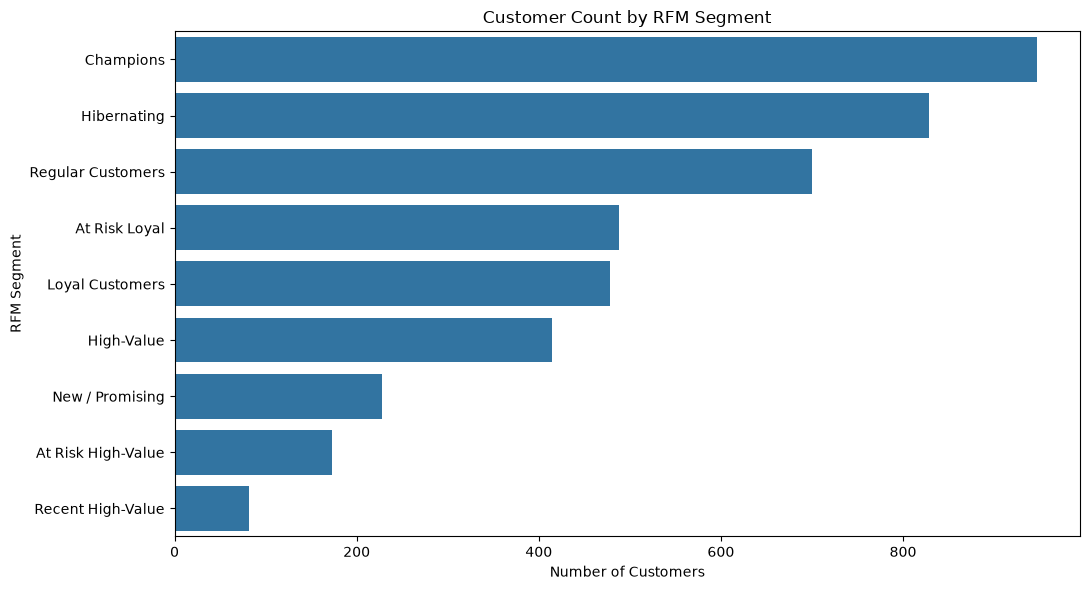

In [13]:
import matplotlib.pyplot as plt
import seaborn as sns

# Customer count by segment
segment_plot = segment_summary.sort_values(
    "Customers",
    ascending=False
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=segment_plot,
    x="Customers",
    y="Segment"
)

plt.title("Customer Count by RFM Segment")
plt.xlabel("Number of Customers")
plt.ylabel("RFM Segment")

plt.tight_layout()
plt.show()

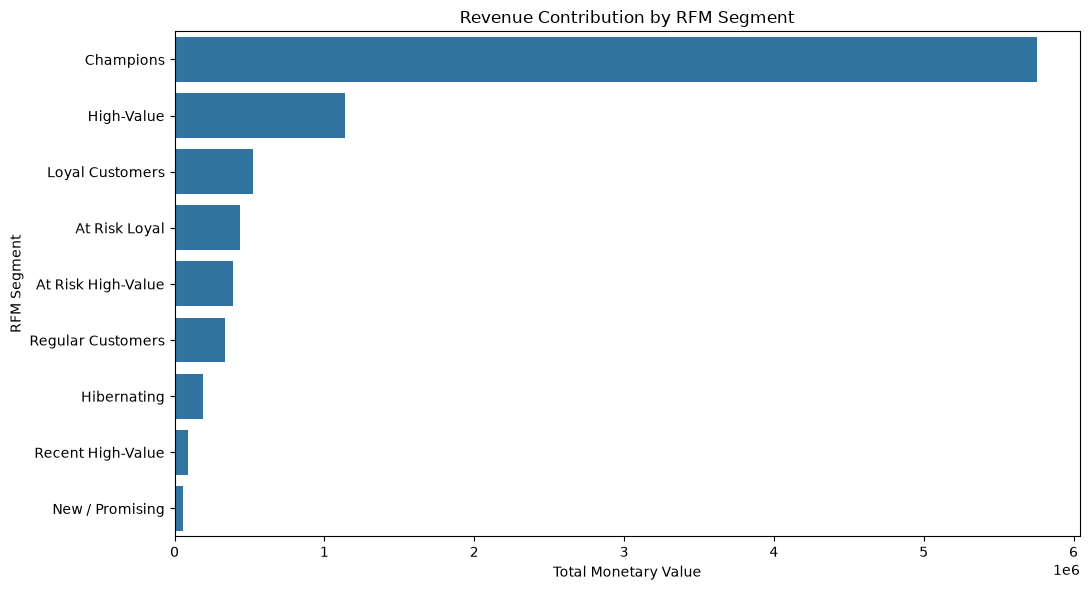

In [14]:
# Revenue contribution by segment

revenue_plot = segment_summary.sort_values(
    "Total_Monetary",
    ascending=False
)

plt.figure(figsize=(11, 6))

sns.barplot(
    data=revenue_plot,
    x="Total_Monetary",
    y="Segment"
)

plt.title("Revenue Contribution by RFM Segment")
plt.xlabel("Total Monetary Value")
plt.ylabel("RFM Segment")

plt.tight_layout()
plt.show()

In [15]:
# Validate segment distinctness using RFM medians

segment_distinctness = (
    rfm.groupby("Segment")
    .agg(
        Customers=("CustomerID", "count"),
        Median_Recency=("Recency", "median"),
        Median_Frequency=("Frequency", "median"),
        Median_Monetary=("Monetary", "median")
    )
    .sort_values("Median_Monetary", ascending=False)
)

print("Segment distinctness check:")
display(segment_distinctness)

print("\nEmpty segments:", segment_distinctness.index.isna().sum())
print("Number of non-empty segments:", len(segment_distinctness))
print("Total customers represented:", segment_distinctness["Customers"].sum())

Segment distinctness check:


,Customers,Median_Recency,Median_Frequency,Median_Monetary
Segment,,,,
Champions,947,10.0,7.0,2638.940
At Risk High-Value,173,106.0,5.0,1793.580
High-Value,414,53.0,4.0,1748.830
Recent High-Value,82,18.0,2.0,735.430
Loyal Customers,478,16.0,3.0,659.015
At Risk Loyal,488,151.5,2.0,594.910
Regular Customers,700,57.5,1.0,499.135
New / Promising,228,19.0,1.0,224.620
Hibernating,828,236.0,1.0,211.410



Empty segments: 0
Number of non-empty segments: 9
Total customers represented: 4338


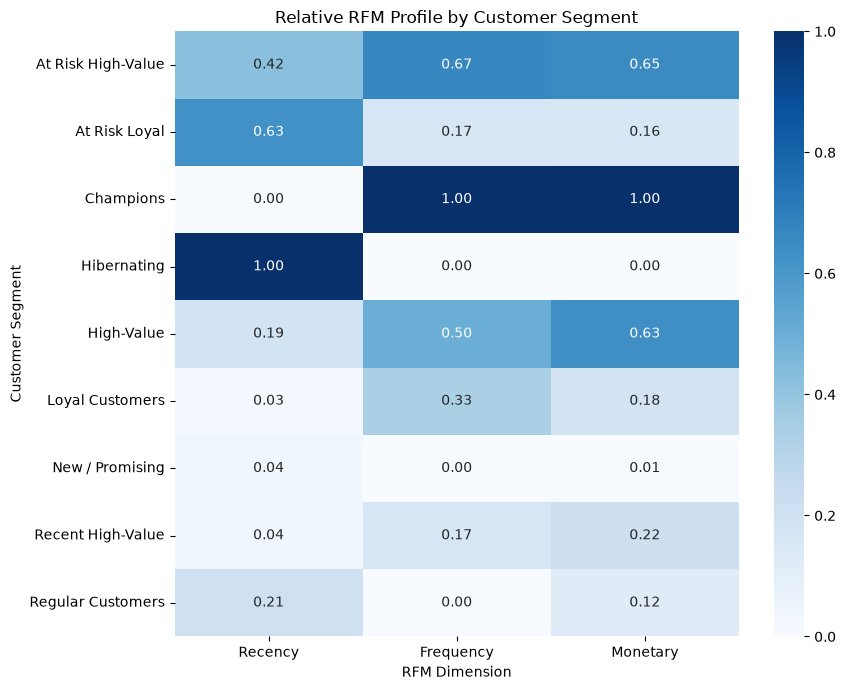

In [16]:
# Compare segment-level RFM behavior visually

heatmap_data = (
    rfm.groupby("Segment")[["Recency", "Frequency", "Monetary"]]
    .median()
)

# Normalize each dimension for visual comparison
heatmap_scaled = heatmap_data.copy()

for column in heatmap_scaled.columns:
    minimum = heatmap_scaled[column].min()
    maximum = heatmap_scaled[column].max()

    if maximum != minimum:
        heatmap_scaled[column] = (
            (heatmap_scaled[column] - minimum)
            / (maximum - minimum)
        )

plt.figure(figsize=(9, 7))

sns.heatmap(
    heatmap_scaled,
    annot=True,
    fmt=".2f",
    cmap="Blues"
)

plt.title("Relative RFM Profile by Customer Segment")
plt.xlabel("RFM Dimension")
plt.ylabel("Customer Segment")

plt.tight_layout()
plt.show()

In [17]:
# Stability / robustness check
# Customers near score boundaries are the most sensitive to small changes.

score_counts = rfm["RFM_total"].value_counts().sort_index()

print("RFM total-score distribution:")
display(score_counts.to_frame("Customers"))

# Compare the lowest and highest score bands
low_score_customers = (rfm["RFM_total"] <= 6).sum()
high_score_customers = (rfm["RFM_total"] >= 12).sum()

print("\nRobustness indicators:")
print("Customers with RFM total <= 6:", low_score_customers)
print("Customers with RFM total >= 12:", high_score_customers)

# Confirm every customer receives exactly one segment
segment_assignment_check = (
    rfm["Segment"].notna().all()
    and (rfm["Segment"].value_counts().sum() == len(rfm))
)

print("\nEvery customer assigned exactly one segment:", segment_assignment_check)

RFM total-score distribution:


,Customers
RFM_total,
3,184
4,364
5,339
6,422
7,383
8,383
9,323
10,349
11,347



Robustness indicators:
Customers with RFM total <= 6: 1309
Customers with RFM total >= 12: 1244

Every customer assigned exactly one segment: True


In [18]:
# Final decision-ready RFM segmentation table

final_segment_table = segment_summary[
    [
        "Segment",
        "Customers",
        "Customer_Share_%",
        "Total_Monetary",
        "Revenue_Share_%",
        "Avg_Recency",
        "Avg_Frequency",
        "Avg_Monetary",
        "Recommended_Action"
    ]
].copy()

final_segment_table = final_segment_table.sort_values(
    "Total_Monetary",
    ascending=False
)

display(
    final_segment_table.round({
        "Customer_Share_%": 2,
        "Total_Monetary": 2,
        "Revenue_Share_%": 2,
        "Avg_Recency": 2,
        "Avg_Frequency": 2,
        "Avg_Monetary": 2
    })
)

print("\nFinal RFM segmentation completed.")
print("Customers segmented:", len(rfm))
print("Segments created:", rfm["Segment"].nunique())
print("Total customer monetary value:",
      round(rfm["Monetary"].sum(), 2))

,Segment,Customers,Customer_Share_%,Total_Monetary,Revenue_Share_%,Avg_Recency,Avg_Frequency,Avg_Monetary,Recommended_Action
2,Champions,947,21.83,5755513.22,64.59,12.54,11.15,6077.63,"Reward and retain: loyalty benefits, early acc..."
4,High-Value,414,9.54,1137373.85,12.76,75.18,4.51,2747.28,"Protect value through personalized service, re..."
5,Loyal Customers,478,11.02,522465.61,5.86,15.66,2.97,1093.02,Increase retention and share of wallet through...
1,At Risk Loyal,488,11.25,436328.43,4.90,160.16,2.67,894.12,"Re-engage with timely reminders, relevant offe..."
0,At Risk High-Value,173,3.99,390109.94,4.38,123.80,5.52,2254.97,Prioritize win-back outreach with personalized...
8,Regular Customers,700,16.14,335815.29,3.77,81.68,1.68,479.74,Nurture toward higher frequency and spend with...
3,Hibernating,828,19.09,190632.99,2.14,227.75,1.04,230.23,Run low-cost reactivation campaigns and suppre...
7,Recent High-Value,82,1.89,87494.35,0.98,17.20,1.59,1067.00,Encourage repeat purchases with personalized r...
6,New / Promising,228,5.26,55674.22,0.62,18.42,1.12,244.19,"Build the relationship with onboarding, produc..."



Final RFM segmentation completed.
Customers segmented: 4338
Segments created: 9
Total customer monetary value: 8911407.9


## Outcome

The UCI Online Retail dataset was used as an explicit real-data substitution because
the project's Titanic dataset does not contain customer transaction history required
for RFM analysis.

The transaction data were cleaned by retaining identifiable customers, excluding
cancellation invoices, and keeping only positive-quantity and positive-price
transactions. RFM values were then calculated at customer level using transaction
recency, distinct invoice frequency, and total monetary spend.

Customers were scored into five RFM tiers using rank-based quintiles and assigned
to actionable segments. Each segment was profiled by customer count, customer
share, monetary value, revenue contribution, and RFM behavior, with a recommended
business action attached to every segment.

The segmentation was validated by checking score distributions, ensuring every
customer received exactly one segment, confirming that no segment was empty, and
comparing the segment-level RFM profiles. The resulting segments should be treated
as a current behavioral snapshot that should be refreshed as new transactions arrive.